# Word2Vec em PyTorch (Google Colab)

Este notebook implementa **Word2Vec no estilo Skip-Gram com Negative Sampling (SGNS)** em PyTorch.

Ele foi escrito para ser:

- **didático**, com a implementação feita do zero;
- **compatível com Google Colab**;
- **executável sem arquivos externos**, usando um corpus de demonstração;
- **fácil de adaptar**, permitindo upload opcional de um arquivo `.txt`.

## O que este notebook cobre

1. pré-processamento do texto;
2. construção do vocabulário;
3. geração de pares `(palavra_central, contexto)`;
4. negative sampling com distribuição unigram\^0.75;
5. modelo Skip-Gram em PyTorch;
6. treinamento;
7. extração de embeddings;
8. busca de palavras mais próximas;
9. projeção 2D para inspeção qualitativa.

## Observação importante

O corpus embutido é **pequeno e sintético**, apenas para demonstração rápida. Para obter embeddings mais úteis, envie um corpus maior.


In [1]:
!pip install -q torch matplotlib scikit-learn tqdm

import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Usando dispositivo:', DEVICE)


Usando dispositivo: cpu


## 1. Corpus

A célula abaixo permite:

- usar um **corpus de demonstração**;
- ou fazer **upload de um `.txt`** no Colab.


In [2]:
USE_UPLOADED_TEXT = False  # troque para True para usar upload no Colab


def build_demo_corpus(repetitions: int = 200) -> str:
    base_sentences = [
        'king is a man',
        'queen is a woman',
        'prince is a young man',
        'princess is a young woman',
        'man and woman are adults',
        'boy and girl are children',
        'father is a man',
        'mother is a woman',
        'brother is a male sibling',
        'sister is a female sibling',
        'paris is the capital of france',
        'berlin is the capital of germany',
        'madrid is the capital of spain',
        'rome is the capital of italy',
        'lisbon is the capital of portugal',
        'france germany spain italy and portugal are countries in europe',
        'apple banana orange and grape are fruits',
        'dog cat horse and rabbit are animals',
        'car bus train and bicycle are vehicles',
        'doctor nurse and surgeon work in hospital',
        'teacher student and school are related to education',
        'python pytorch and code are related to machine learning',
        'data model training and inference are common terms in artificial intelligence',
        'coffee tea milk and water are drinks',
    ]
    return '. '.join(base_sentences * repetitions)


if USE_UPLOADED_TEXT:
    try:
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        if not uploaded:
            raise ValueError('Nenhum arquivo enviado.')
        filename = next(iter(uploaded.keys()))
        text = uploaded[filename].decode('utf-8', errors='ignore')
        print(f'Arquivo carregado: {filename}')
    except Exception as exc:
        print('Upload não disponível ou falhou. Usando corpus de demonstração.')
        print('Motivo:', exc)
        text = build_demo_corpus()
else:
    text = build_demo_corpus()

print(text[:500])
print('\nTamanho do corpus em caracteres:', len(text))


king is a man. queen is a woman. prince is a young man. princess is a young woman. man and woman are adults. boy and girl are children. father is a man. mother is a woman. brother is a male sibling. sister is a female sibling. paris is the capital of france. berlin is the capital of germany. madrid is the capital of spain. rome is the capital of italy. lisbon is the capital of portugal. france germany spain italy and portugal are countries in europe. apple banana orange and grape are fruits. dog

Tamanho do corpus em caracteres: 168998


## 2. Pré-processamento e tokenização

In [3]:
def preprocess_text(raw_text: str):
    raw_text = raw_text.lower()
    raw_text = re.sub(r'[^a-zà-ÿ0-9\s]', ' ', raw_text)
    raw_text = re.sub(r'\s+', ' ', raw_text).strip()
    tokens = raw_text.split()
    return tokens


tokens = preprocess_text(text)
print('Número de tokens:', len(tokens))
print('Amostra:', tokens[:30])


Número de tokens: 29800
Amostra: ['king', 'is', 'a', 'man', 'queen', 'is', 'a', 'woman', 'prince', 'is', 'a', 'young', 'man', 'princess', 'is', 'a', 'young', 'woman', 'man', 'and', 'woman', 'are', 'adults', 'boy', 'and', 'girl', 'are', 'children', 'father', 'is']


## 3. Vocabulário

Abaixo filtramos palavras muito raras e construímos os mapeamentos `word2idx` e `idx2word`.


In [4]:
MIN_FREQ = 1

counter = Counter(tokens)
vocab = [word for word, freq in counter.items() if freq >= MIN_FREQ]
vocab.sort()

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}
encoded_tokens = [word2idx[word] for word in tokens if word in word2idx]

print('Tamanho do vocabulário:', len(vocab))
print('10 palavras mais frequentes:', counter.most_common(10))


Tamanho do vocabulário: 82
10 palavras mais frequentes: [('is', 2600), ('and', 2200), ('are', 2000), ('a', 1600), ('the', 1000), ('capital', 1000), ('of', 1000), ('man', 800), ('woman', 800), ('in', 600)]


## 4. Geração dos pares Skip-Gram

Para cada palavra central, geramos pares positivos com palavras de contexto em uma janela simétrica.


In [5]:
WINDOW_SIZE = 2


def generate_skipgram_pairs(token_ids, window_size):
    pairs = []
    for i, center in enumerate(token_ids):
        left = max(0, i - window_size)
        right = min(len(token_ids), i + window_size + 1)
        for j in range(left, right):
            if i == j:
                continue
            context = token_ids[j]
            pairs.append((center, context))
    return pairs


pairs = generate_skipgram_pairs(encoded_tokens, WINDOW_SIZE)
print('Quantidade de pares positivos:', len(pairs))
print('Amostra:', pairs[:10])
print('Amostra decodificada:', [(idx2word[c], idx2word[o]) for c, o in pairs[:10]])


Quantidade de pares positivos: 119194
Amostra: [(41, 39), (41, 0), (39, 41), (39, 0), (39, 47), (0, 41), (0, 39), (0, 47), (0, 60), (47, 39)]
Amostra decodificada: [('king', 'is'), ('king', 'a'), ('is', 'king'), ('is', 'a'), ('is', 'man'), ('a', 'king'), ('a', 'is'), ('a', 'man'), ('a', 'queen'), ('man', 'is')]


## 5. Negative Sampling

Usamos a distribuição unigram elevada a `0.75`, como é comum em implementações de Word2Vec.


In [6]:
NEGATIVE_SAMPLES = 5

freqs = torch.tensor([counter[idx2word[i]] for i in range(len(vocab))], dtype=torch.float)
negative_sampling_dist = freqs.pow(0.75)
negative_sampling_dist = negative_sampling_dist / negative_sampling_dist.sum()

print('Soma da distribuição:', negative_sampling_dist.sum().item())


Soma da distribuição: 1.0000001192092896


## 6. Dataset e DataLoader

In [7]:
class Word2VecDataset(Dataset):
    def __init__(self, positive_pairs, negative_dist, num_negative_samples):
        self.positive_pairs = positive_pairs
        self.negative_dist = negative_dist
        self.num_negative_samples = num_negative_samples

    def __len__(self):
        return len(self.positive_pairs)

    def __getitem__(self, idx):
        center, context = self.positive_pairs[idx]
        negatives = torch.multinomial(
            self.negative_dist,
            self.num_negative_samples,
            replacement=True,
        )
        return (
            torch.tensor(center, dtype=torch.long),
            torch.tensor(context, dtype=torch.long),
            negatives.long(),
        )


dataset = Word2VecDataset(pairs, negative_sampling_dist, NEGATIVE_SAMPLES)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

batch_center, batch_context, batch_neg = next(iter(loader))
print(batch_center.shape, batch_context.shape, batch_neg.shape)


torch.Size([256]) torch.Size([256]) torch.Size([256, 5])


## 7. Modelo Word2Vec (Skip-Gram + Negative Sampling)

Temos duas matrizes de embedding:

- `in_embeddings`: vetor da palavra central;
- `out_embeddings`: vetor da palavra de contexto.


In [8]:
class Word2VecSGNS(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

        self.in_embeddings.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        self.out_embeddings.weight.data.zero_()

    def forward(self, center_words, positive_context_words, negative_context_words):
        center_emb = self.in_embeddings(center_words)                    # [B, D]
        positive_emb = self.out_embeddings(positive_context_words)       # [B, D]
        negative_emb = self.out_embeddings(negative_context_words)       # [B, K, D]

        positive_score = torch.sum(center_emb * positive_emb, dim=1)     # [B]
        positive_loss = F.logsigmoid(positive_score)

        negative_score = torch.bmm(negative_emb, center_emb.unsqueeze(2)).squeeze(2)  # [B, K]
        negative_loss = F.logsigmoid(-negative_score).sum(dim=1)

        loss = -(positive_loss + negative_loss).mean()
        return loss

    def get_embeddings(self):
        return self.in_embeddings.weight.detach().cpu()


## 8. Treinamento

In [11]:
EMBEDDING_DIM = 50
EPOCHS = 50
LEARNING_RATE = 0.003

model = Word2VecSGNS(len(vocab), EMBEDDING_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    progress = tqdm(loader, desc=f'Epoch {epoch + 1}/{EPOCHS}')
    for center_words, context_words, negative_words in progress:
        center_words = center_words.to(DEVICE)
        context_words = context_words.to(DEVICE)
        negative_words = negative_words.to(DEVICE)

        optimizer.zero_grad()
        loss = model(center_words, context_words, negative_words)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f'{loss.item():.4f}')

    mean_loss = total_loss / len(loader)
    history.append(mean_loss)
    print(f'Epoch {epoch + 1}: loss média = {mean_loss:.4f}')


Epoch 1/50:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 1: loss média = 2.2607


Epoch 2/50:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 2: loss média = 1.2988


Epoch 3/50:   0%|          | 0/466 [00:00<?, ?it/s]

...

Epoch 48: loss média = 1.2040


Epoch 49/50:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 49: loss média = 1.2004


Epoch 50/50:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 50: loss média = 1.2051


## 9. Curva de treinamento

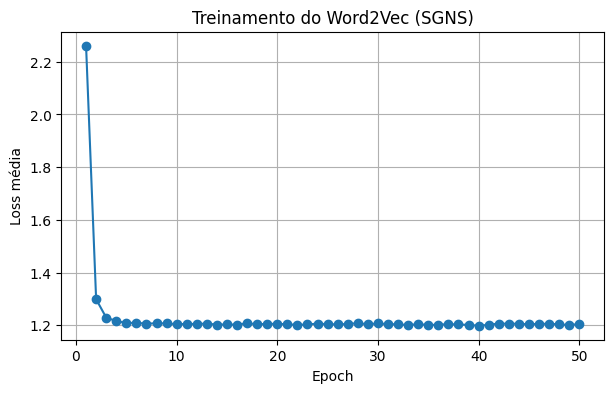

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history) + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss média')
plt.title('Treinamento do Word2Vec (SGNS)')
plt.grid(True)
plt.show()


## 10. Extração dos embeddings

In [13]:
embeddings = model.get_embeddings()
print('Shape da matriz de embeddings:', embeddings.shape)


Shape da matriz de embeddings: torch.Size([82, 50])


## 11. Função para buscar palavras mais próximas

In [14]:
def most_similar(word, embeddings_tensor, word_to_idx, idx_to_word, top_k=5):
    if word not in word_to_idx:
        raise ValueError(f'Palavra não encontrada no vocabulário: {word}')

    vectors = F.normalize(embeddings_tensor, dim=1)
    word_vector = vectors[word_to_idx[word]]
    similarities = torch.mv(vectors, word_vector)

    best_indices = torch.topk(similarities, top_k + 1).indices.tolist()
    results = []
    for idx in best_indices:
        candidate = idx_to_word[idx]
        if candidate == word:
            continue
        results.append((candidate, float(similarities[idx])))
        if len(results) == top_k:
            break
    return results


In [15]:
for query in ['king', 'queen', 'paris', 'france', 'doctor', 'python']:
    if query in word2idx:
        print(f'\nPalavra: {query}')
        for neighbor, score in most_similar(query, embeddings, word2idx, idx2word, top_k=5):
            print(f'  {neighbor:12s}  {score:.4f}')



Palavra: king
  father        0.7280
  water         0.6815
  queen         0.6434
  mother        0.6326
  male          0.6082

Palavra: queen
  mother        0.9992
  young         0.8626
  princess      0.8548
  woman         0.7212
  brother       0.6909

Palavra: paris
  madrid        0.7209
  berlin        0.6967
  capital       0.6782
  rome          0.6641
  female        0.6634

Palavra: france
  italy         0.7326
  madrid        0.6827
  the           0.6666
  capital       0.6387
  rome          0.6160

Palavra: doctor
  bicycle       0.8163
  surgeon       0.6921
  vehicles      0.6912
  nurse         0.6497
  code          0.6155

Palavra: python
  code          0.6860
  education     0.6667
  pytorch       0.6588
  related       0.6144
  learning      0.5780


## 12. Analogia vetorial simples

Como o corpus é pequeno, esta etapa é apenas ilustrativa.


In [16]:
def analogy(a, b, c, embeddings_tensor, word_to_idx, idx_to_word, top_k=5):
    for w in [a, b, c]:
        if w not in word_to_idx:
            raise ValueError(f'Palavra ausente do vocabulário: {w}')

    vectors = F.normalize(embeddings_tensor, dim=1)
    query = vectors[word_to_idx[b]] - vectors[word_to_idx[a]] + vectors[word_to_idx[c]]
    query = F.normalize(query.unsqueeze(0), dim=1).squeeze(0)
    similarities = torch.mv(vectors, query)

    forbidden = {a, b, c}
    best_indices = torch.topk(similarities, top_k + len(forbidden)).indices.tolist()

    results = []
    for idx in best_indices:
        candidate = idx_to_word[idx]
        if candidate in forbidden:
            continue
        results.append((candidate, float(similarities[idx])))
        if len(results) == top_k:
            break
    return results


examples = [
    ('man', 'king', 'woman'),
    ('france', 'paris', 'germany'),
]

for a, b, c in examples:
    if all(w in word2idx for w in [a, b, c]):
        print(f'\n{a} : {b} :: {c} : ?')
        print(analogy(a, b, c, embeddings, word2idx, idx2word, top_k=5))



man : king :: woman : ?
[('boy', 0.5730161666870117), ('water', 0.5567384958267212), ('queen', 0.5522973537445068), ('mother', 0.5511966943740845), ('father', 0.5132352113723755)]

france : paris :: germany : ?
[('berlin', 0.6265202760696411), ('sister', 0.6137967705726624), ('lisbon', 0.5828697085380554), ('capital', 0.5495032668113708), ('female', 0.5248599052429199)]


## 13. Visualização 2D com PCA

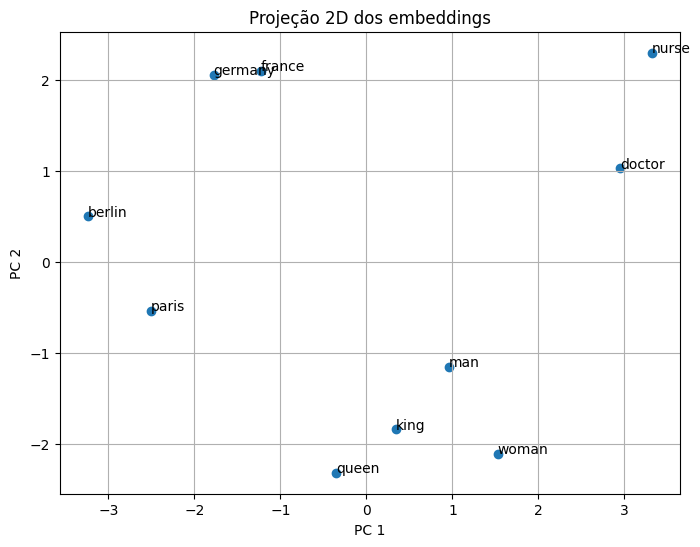

In [17]:
def plot_words_2d(words, embeddings_tensor, word_to_idx):
    valid_words = [w for w in words if w in word_to_idx]
    if len(valid_words) < 2:
        raise ValueError('É preciso ter pelo menos 2 palavras válidas para plotar.')

    vectors = torch.stack([embeddings_tensor[word_to_idx[w]] for w in valid_words]).numpy()
    coords = PCA(n_components=2).fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1])
    for i, word in enumerate(valid_words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]))
    plt.title('Projeção 2D dos embeddings')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.grid(True)
    plt.show()


plot_words_2d(
    ['king', 'queen', 'man', 'woman', 'paris', 'france', 'berlin', 'germany', 'doctor', 'nurse'],
    embeddings,
    word2idx,
)


## 14. Próximos passos

Para transformar este notebook em algo mais próximo de um Word2Vec de uso real, os próximos passos naturais são:

1. usar um corpus muito maior;
2. aplicar tratamento melhor de tokenização;
3. testar subsampling de palavras muito frequentes;
4. comparar Skip-Gram com CBOW;
5. salvar embeddings em disco;
6. avaliar qualitativamente e quantitativamente em tarefas de similaridade/analogia.
